 # Task - Disciplinary Cards
This part of the analysis looks at yellow cards issued in FIFA World Cup 2026 matches.

The main objective is to find the average number of yellow cards per completed match. Compare the difference in yellow card during the Group Stage and Knockout Stage and additionally check if there is any relationship between fouls and yellow cards.
    

## Analytic Questions Formulation

**Main question:** What was the average number of yellow cards issued per completed match at the FIFA World Cup 2026?

**Comparative question:** Did the average number of yellow cards per match differ between Group Stage and Knockout Stage matches?

**Additional question:** Is there a relationship between the number of fouls and the number of yellow cards in a match?
    

## Importing the required libraries

    

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import seaborn as sns
    

## Dataset Information

The dataset contains match-level information from the FIFA World Cup 2026. Each row represents one completed match.

There are 104 matches and 29 columns in the original dataset. The columns include information about the match stage, teams, scores, goals, cards, corners, expected goals, shots and fouls.

### Description of Variables

| Column | Description |
|---|---|
| `Stage` | Tournament stage where the match was played, such as Group Stage, Round of 32, Round of 16, Quarter Finals, Semi Finals, Third place and Final. |
| `Date` | Date on which the match was played. |
| `Team1` | Name of the first team in the match. |
| `Team2` | Name of the second team in the match. |
| `T1score` | Total goals scored by Team 1. |
| `T2score` | Total goals scored by Team 2. |
| `T1goalsH1` | Goals scored by Team 1 in the first half. |
| `T2goalsH1` | Goals scored by Team 2 in the first half. |
| `T1goalsH2` | Goals scored by Team 1 in the second half. |
| `T2goalsH2` | Goals scored by Team 2 in the second half. |
| `T1cardsYel` | Yellow cards received by Team 1. |
| `T2cardsYel` | Yellow cards received by Team 2. |
| `T1cardsRed` | Red cards received by Team 1. |
| `T2cardsRed` | Red cards received by Team 2. |
| `T1corners1H` | Corner kicks taken by Team 1 in the first half. |
| `T2corners1H` | Corner kicks taken by Team 2 in the first half. |
| `T1corners2H` | Corner kicks taken by Team 1 in the second half. |
| `T2corners2H` | Corner kicks taken by Team 2 in the second half. |
| `T1cornersTotal` | Total corner kicks taken by Team 1. |
| `T2cornersTotal` | Total corner kicks taken by Team 2. |
| `CornersTotal` | Total corner kicks taken by both teams. |
| `T1xG` | Expected goals (xG) value for Team 1. |
| `T2xG` | Expected goals (xG) value for Team 2. |
| `T1shots` | Total shots attempted by Team 1. |
| `T2shots` | Total shots attempted by Team 2. |
| `T1shotsOnTarget` | Shots on target by Team 1. |
| `T2shotsOnTarget` | Shots on target by Team 2. |
| `T1fouls` | Fouls committed by Team 1. |
| `T2fouls` | Fouls committed by Team 2. |

    

## Load the dataset

loading the CSV file. Each row represents one match.
    

In [2]:
df = pd.read_csv("match_data.csv")
    

### Viewing the first 10 rows

    

In [3]:
df.head(10)
    

,Stage,Date,Team1,Team2,T1score,T2score,T1goalsH1,T2goalsH1,T1goalsH2,T2goalsH2,...,T2cornersTotal,CornersTotal,T1xG,T2xG,T1shots,T2shots,T1shotsOnTarget,T2shotsOnTarget,T1fouls,T2fouls
0,Group Stage,11/06/2026,Mexico,South Africa,2,0,1,0,1,0,...,1,4,1.46,0.07,16,3,4,2,12,11
1,Group Stage,12/06/2026,South Korea,Czech Republic,2,1,0,0,2,1,...,5,9,2.30,0.83,15,7,6,4,9,16
2,Group Stage,12/06/2026,Canada,Bosnia & Herzegovina,1,1,0,1,1,0,...,4,13,1.25,0.98,13,8,4,3,10,20
3,Group Stage,13/06/2026,USA,Paraguay,4,1,3,0,1,1,...,1,4,1.42,0.54,16,9,6,1,13,17
4,Group Stage,13/06/2026,Qatar,Switzerland,1,1,0,1,1,0,...,10,13,0.60,3.20,6,26,3,7,12,11
5,Group Stage,13/06/2026,Brazil,Morocco,1,1,1,1,0,0,...,2,8,1.26,1.37,12,14,5,3,16,14
6,Group Stage,14/06/2026,Haiti,Scotland,0,1,0,1,0,0,...,3,7,1.05,1.05,15,9,2,2,23,21
7,Group Stage,14/06/2026,Australia,Turkey,2,0,1,0,1,0,...,8,13,1.18,1.36,9,30,4,8,12,4
8,Group Stage,14/06/2026,Germany,Curacao,7,1,3,1,4,0,...,1,9,4.22,0.41,26,8,12,2,18,11
9,Group Stage,14/06/2026,Netherlands,Japan,2,2,0,0,2,2,...,4,9,0.78,0.59,10,10,6,3,7,7


### Checking the columns
    

In [4]:
df.columns
    

Index(['Stage', 'Date', 'Team1', 'Team2', 'T1score', 'T2score', 'T1goalsH1',
       'T2goalsH1', 'T1goalsH2', 'T2goalsH2', 'T1cardsYel', 'T2cardsYel',
       'T1cardsRed', 'T2cardsRed', 'T1corners1H', 'T2corners1H', 'T1corners2H',
       'T2corners2H', 'T1cornersTotal', 'T2cornersTotal', 'CornersTotal',
       'T1xG', 'T2xG', 'T1shots', 'T2shots', 'T1shotsOnTarget',
       'T2shotsOnTarget', 'T1fouls', 'T2fouls'],
      dtype='str')

### Checking the size

The dataset should contain 104 completed matches and 29 original variables.
    

In [5]:
print(df.shape)
    

(104, 29)


### Basic information

checking the data types and make sure proper loading is done with the dataset.
    

In [6]:
df.info()
    

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Stage            104 non-null    str    
 1   Date             104 non-null    str    
 2   Team1            104 non-null    str    
 3   Team2            104 non-null    str    
 4   T1score          104 non-null    str    
 5   T2score          104 non-null    str    
 6   T1goalsH1        104 non-null    int64  
 7   T2goalsH1        104 non-null    int64  
 8   T1goalsH2        104 non-null    int64  
 9   T2goalsH2        104 non-null    int64  
 10  T1cardsYel       104 non-null    int64  
 11  T2cardsYel       104 non-null    int64  
 12  T1cardsRed       104 non-null    int64  
 13  T2cardsRed       104 non-null    int64  
 14  T1corners1H      104 non-null    int64  
 15  T2corners1H      104 non-null    int64  
 16  T1corners2H      104 non-null    int64  
 17  T2corners2H      104 non-nu

## Data Wrangling and Processing

## Selecting relevant variables

The original dataset has many variables that are not needed for this task, such as goals, corners, xG and shots.

Since this is a disciplinary cards analysis, keeping the variables that are useful for the questions. This reduces unnecessary processing and makes the analysis easier to follow.

keeping the date and team names because they can be used to identify a particular match, and removing other irrelevant columns
    

In [7]:
cards_df = df[
        ["Stage","Date","Team1","Team2","T1cardsYel","T2cardsYel","T1fouls","T2fouls"]
    ].copy()

print(cards_df.shape)
cards_df.head()
    

(104, 8)


,Stage,Date,Team1,Team2,T1cardsYel,T2cardsYel,T1fouls,T2fouls
0,Group Stage,11/06/2026,Mexico,South Africa,1,2,12,11
1,Group Stage,12/06/2026,South Korea,Czech Republic,1,0,9,16
2,Group Stage,12/06/2026,Canada,Bosnia & Herzegovina,2,3,10,20
3,Group Stage,13/06/2026,USA,Paraguay,1,5,13,17
4,Group Stage,13/06/2026,Qatar,Switzerland,2,1,12,11


## Checking missing values and duplicate matches

Before doing the calculations, checking whether selected variables contain missing values. also checking for duplicate matches using the date and team names.
    

In [8]:
print("Missing values:")
print(cards_df.isnull().sum())

print("\nDuplicate matches:")
print(cards_df[["Date", "Team1", "Team2"]].duplicated().sum())
    

Missing values:
Stage         0
Date          0
Team1         0
Team2         0
T1cardsYel    0
T2cardsYel    0
T1fouls       0
T2fouls       0
dtype: int64

Duplicate matches:
0


So No missing values

## Data Wrangling

The yellow cards are stored separately for Team 1 and Team 2, so combining them to get the total number of yellow cards in each match.

Also combining the fouls from both teams. This gives `TotalFouls`, which will be used for the additional analysis.
    

In [9]:
cards_df["TotalYellow"] = (cards_df["T1cardsYel"] + cards_df["T2cardsYel"])

cards_df["TotalFouls"] = (cards_df["T1fouls"] + cards_df["T2fouls"])

cards_df.head()
    

,Stage,Date,Team1,Team2,T1cardsYel,T2cardsYel,T1fouls,T2fouls,TotalYellow,TotalFouls
0,Group Stage,11/06/2026,Mexico,South Africa,1,2,12,11,3,23
1,Group Stage,12/06/2026,South Korea,Czech Republic,1,0,9,16,1,25
2,Group Stage,12/06/2026,Canada,Bosnia & Herzegovina,2,3,10,20,5,30
3,Group Stage,13/06/2026,USA,Paraguay,1,5,13,17,6,30
4,Group Stage,13/06/2026,Qatar,Switzerland,2,1,12,11,3,23


### Variables created during analysis

so from above output, we can see the created columns by combining

| Variable | Description |
|---|---|
| `TotalYellow` | Total yellow cards in a match, calculated from both teams. |
| `TotalFouls` | Total fouls in a match, calculated from both teams. |

`TotalYellow` is the main variable for this task. `TotalFouls` is included as an additional disciplinary variable.
    

## Distribution of yellow cards

Before sampling, interpreting how the total yellow cards are distributed across all 104 matches.
using matplotlib for the purpose

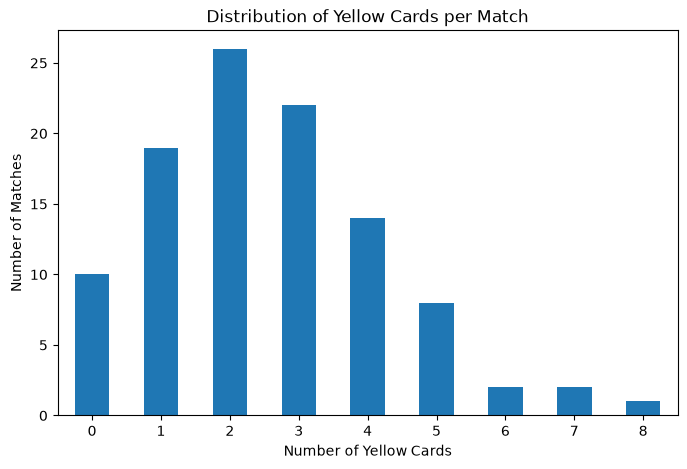

In [10]:
plt.figure(figsize=(8,5))

cards_df["TotalYellow"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Yellow Cards per Match")
plt.xlabel("Number of Yellow Cards")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.show()
    

From the above output, we can visualize that, 2 and 3 yellow cards we issued for most of the matches across the world cup 2026. 

checking the exact figures in number : 

In [11]:
print(cards_df["TotalYellow"].value_counts().sort_index())

TotalYellow
0    10
1    19
2    26
3    22
4    14
5     8
6     2
7     2
8     1
Name: count, dtype: int64


So, out of 104 matches, 2 yellow card were give in highest of 26 matches while 3 yellow cards were given acrross 22 matches in the worldcup.

### Full data summary

These statistics give an initial idea of the number of yellow cards in the full 104-match dataset.
    

In [12]:
print(cards_df["TotalYellow"].describe())
    

count    104.000000
mean       2.567308
std        1.688133
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max        8.000000
Name: TotalYellow, dtype: float64


So from above results, we can see that 2.56 no of yellows cards were issued per match in average in Fifa World cup 2026

 ## Checking the match stages

checking how many matches are in each stage. Later combining these into Group Stage and Knockout Stage for the comparison as formulated in the analytic question
    

In [13]:
print(cards_df["Stage"].value_counts())
print("\nStage names:")

print(cards_df["Stage"].unique())
    

Stage
Group Stage       72
Round of 32       16
Round of 16        8
Quarter Finals     4
Semi Finals        2
Third place        1
Final              1
Name: count, dtype: int64

Stage names:
<StringArray>
[   'Group Stage',    'Round of 32',    'Round of 16', 'Quarter Finals',
    'Semi Finals',    'Third place',          'Final']
Length: 7, dtype: str


This actually matches with the exact data of the 2026 world cup 

Now viewing the yellow card statistics across different stages. We can use the inbuilt 'groupby' and 'agg' method for grouping and aggregation

In [14]:
print(cards_df.groupby("Stage")["TotalYellow"].agg(["count", "mean", "std"]))
    

                count      mean       std
Stage                                    
Final               1  5.000000       NaN
Group Stage        72  2.472222  1.626993
Quarter Finals      4  2.750000  2.061553
Round of 16         8  3.750000  2.187628
Round of 32        16  2.250000  1.437591
Semi Finals         2  3.500000  0.707107
Third place         1  0.000000       NaN


## Create StageGroup

For the main comparison, I use two groups. The Group Stage stays as one group and all the later tournament rounds are combined as Knockout Stage.
    

In [15]:
# Extracting the column names for the stages in the knockout rounds
knockout_stages = ["Round of 32","Round of 16","Quarter Finals","Semi Finals","Third place","Final"]

#creating a stagegroup column to categorize using apply function 
cards_df["StageGroup"] = cards_df["Stage"].apply(lambda x: "Knockout Stage" if x in knockout_stages else "Group Stage")


In [16]:
print(cards_df["StageGroup"].value_counts())

print("\nGrouping:\n")
print(pd.crosstab(cards_df["Stage"], cards_df["StageGroup"]))
    

StageGroup
Group Stage       72
Knockout Stage    32
Name: count, dtype: int64

Grouping:

StageGroup      Group Stage  Knockout Stage
Stage                                      
Final                     0               1
Group Stage              72               0
Quarter Finals            0               4
Round of 16               0               8
Round of 32               0              16
Semi Finals               0               2
Third place               0               1


The grouping is sucessfully done as Knockout stages and Group stage

## Preparing the sample

The population in this dataset contains 104 completed matches.

There are 72 Group Stage matches and 32 Knockout Stage matches. Using proportionate stratified random sampling because the later analysis compares these two groups.

For a sample of 40 matches, I selected 28 Group Stage matches and 12 Knockout Stage matches. This keeps the sample proportions close to the population proportions.
    

In [17]:
group_df = cards_df[cards_df["StageGroup"] == "Group Stage"]
knockout_df = cards_df[cards_df["StageGroup"] == "Knockout Stage"]

print("Group Stage population:", len(group_df))
print("Knockout Stage population:", len(knockout_df))
    

Group Stage population: 72
Knockout Stage population: 32


### Stratified random sample

I use `random_state=42` so that the same sample can be reproduced.
    

In [18]:
group_sample = group_df.sample(
        n=28,
        random_state=42
    )

knockout_sample = knockout_df.sample(
        n=12,
        random_state=42
    )

sample_df = pd.concat(
        [group_sample, knockout_sample]
    ).reset_index(drop=True)

print("Sample size:", len(sample_df))
print(sample_df["StageGroup"].value_counts())
    

Sample size: 40
StageGroup
Group Stage       28
Knockout Stage    12
Name: count, dtype: int64


### Checking population and sample proportions

The population has 72 Group Stage and 32 Knockout Stage matches. The sample has 28 and 12 respectively, so the proportions are very similar.
    

                Population  Sample
StageGroup                        
Group Stage             72      28
Knockout Stage          32      12


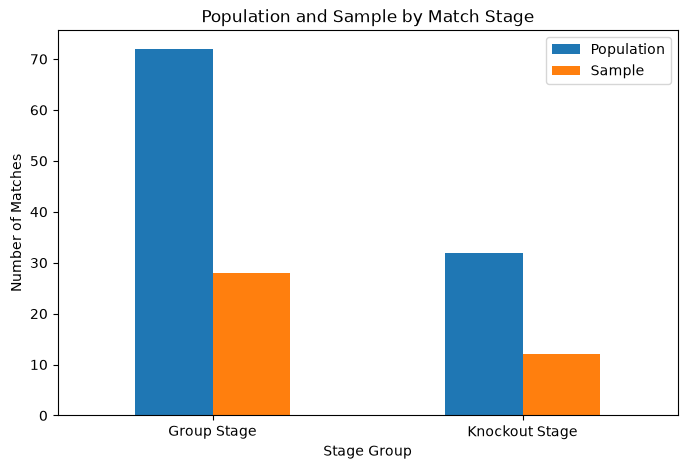

In [29]:
stage_counts = pd.DataFrame({
        "Population": cards_df["StageGroup"].value_counts(), "Sample": sample_df["StageGroup"].value_counts()
    })

print(stage_counts)

stage_counts.plot(
        kind="bar",
        figsize=(8,5)
    )

plt.title("Population and Sample by Match Stage")
plt.xlabel("Stage Group")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.show()
    

In [20]:
print("Duplicate matches in sample:",sample_df[["Date", "Team1", "Team2"]].duplicated().sum())
    

Duplicate matches in sample: 0


## Descriptive statistics

Calculating the main descriptive statistics for the sample of 40 matches. The mean is especially important because the main question asks for the average number of yellow cards.
    

In [21]:
print(sample_df["TotalYellow"].describe())
    

count    40.000000
mean      2.625000
std       1.890428
min       0.000000
25%       1.000000
50%       3.000000
75%       3.250000
max       8.000000
Name: TotalYellow, dtype: float64


In [22]:
print(sample_df["TotalYellow"].value_counts().sort_index())
    

TotalYellow
0     6
1     5
2     8
3    11
4     5
5     2
6     1
7     1
8     1
Name: count, dtype: int64


### Compare by stage

Now comparing the descriptive statistics for Group Stage and Knockout Stage. The means and standard deviations will also be useful for the t-test.
    

using groupby to filter by group and knockout stage and computing their general statistics

In [23]:
stage_summary = sample_df.groupby("StageGroup")["TotalYellow"].agg(
        ["count", "mean", "median", "std", "min", "max"]
    )

print(stage_summary)
    

                count      mean  median       std  min  max
StageGroup                                                 
Group Stage        28  2.571429     3.0  1.772811    0    7
Knockout Stage     12  2.750000     2.0  2.220770    0    8


### Boxplot

The boxplot gives a visual comparison of the number of yellow cards in the two stage groups. The means are quite close, but the spread of the observations can be different.
    

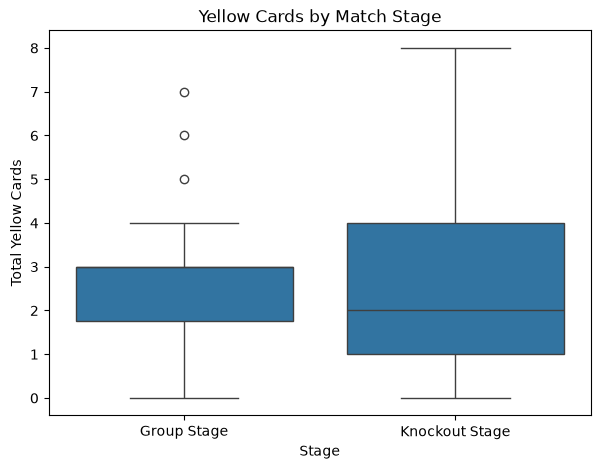

In [24]:
plt.figure(figsize=(7,5))

sns.boxplot(
        data=sample_df,
        x="StageGroup",
        y="TotalYellow"
    )

plt.title("Yellow Cards by Match Stage")
plt.xlabel("Stage")
plt.ylabel("Total Yellow Cards")
plt.show()  
    

## 95% Confidence Interval

Because the sample was selected using stratified sampling, calculating weighted estimate of the overall mean. The weights are based on the actual population sizes of the two strata.

The weighted mean is:

**Group Stage proportion × Group Stage mean + Knockout Stage proportion × Knockout Stage mean**

Using the standard error of the stratified estimate and a Satterthwaite degrees-of-freedom approximation to calculate the 95% confidence interval.
    

In [ ]:
# population sizes
N_group = len(group_df)
N_knockout = len(knockout_df)
N_total = len(cards_df)

# sample sizes
n_group = len(group_sample)
n_knockout = len(knockout_sample)

# population proportions used as stratum weights
W_group = N_group / N_total
W_knockout = N_knockout / N_total

# sample means and standard deviations
mean_group = group_sample["TotalYellow"].mean()
mean_knockout = knockout_sample["TotalYellow"].mean()

sd_group = group_sample["TotalYellow"].std()
sd_knockout = knockout_sample["TotalYellow"].std()

# weighted stratified mean
stratified_mean = (
        W_group * mean_group + W_knockout * mean_knockout
    )

# standard error of the stratified mean
var_group = (W_group ** 2) * (sd_group ** 2) / n_group
var_knockout = (W_knockout ** 2) * (sd_knockout ** 2) / n_knockout

se_stratified = np.sqrt(var_group + var_knockout)

# Satterthwaite degrees of freedom
df_satterthwaite = (
        (var_group + var_knockout) ** 2 /
        (
            (var_group ** 2) / (n_group - 1) + (var_knockout ** 2) / (n_knockout - 1)
        )
    )

confidence = 0.95

t_critical = stats.t.ppf(
        1 - (1 - confidence) / 2,
        df_satterthwaite
    )

margin_error = t_critical * se_stratified

lower = stratified_mean - margin_error
upper = stratified_mean + margin_error

print("Weighted sample mean:", stratified_mean)
print("Standard error:", se_stratified)
print("Degrees of freedom:", df_satterthwaite)
print("Margin of error:", margin_error)
print("95% Confidence Interval:", (lower, upper))
    

Weighted sample mean: 2.626373626373627
Standard error: 0.30447932383287474
Degrees of freedom: 35.105260398153185
Margin of error: 0.6180596423405107
95% Confidence Interval: (np.float64(2.008313984033116), np.float64(3.2444332687141375))


 ### Confidence interval interpretation

The estimated average number of yellow cards per completed match is about **2.63 cards per match**.

The 95% confidence interval is approximately **2.01 to 3.24 yellow cards per match**.

This interval gives a range for the estimated overall mean based on the stratified sample.
    

## Two-sample t-test

The second question is whether the average number of yellow cards differs between Group Stage and Knockout Stage matches.

### Hypothesis Formulation

**H0:** The mean number of yellow cards is the same for Group Stage and Knockout Stage matches.

**H1:** The mean number of yellow cards is different between the two stages.

Using Welch's independent two-sample t-test because it does not require the two groups to have equal variances.

chosen significance level is **0.05**.
    

In [31]:
group_yellow = sample_df[
        sample_df["StageGroup"] == "Group Stage"
    ]["TotalYellow"]

knockout_yellow = sample_df[
        sample_df["StageGroup"] == "Knockout Stage"
    ]["TotalYellow"]

t_stat, p_value = stats.ttest_ind(
        group_yellow,
        knockout_yellow,
        equal_var=False
    )

print("Group Stage mean:", group_yellow.mean())
print("Knockout Stage mean:", knockout_yellow.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value)
    

Group Stage mean: 2.5714285714285716
Knockout Stage mean: 2.75
t-statistic: -0.24686854637714992
p-value: 0.8079151284578333


### T-test result

The Group Stage sample mean is about **2.57** yellow cards per match and the Knockout Stage mean is about **2.75**.

The p-value is about **0.808**, which is much higher than 0.05. Therefore, I fail to reject the null hypothesis.

Based on this sample, there is not enough statistical evidence to say that the average number of yellow cards differs between Group Stage and Knockout Stage matches.
    

## Additional analysis : Fouls and yellow cards

Fouls are also related to disciplinary behaviour, so I use `TotalFouls` to see whether matches with more fouls also tend to have more yellow cards.

This is an additional exploratory analysis and does not replace the required t-test.
    

In [32]:
foul_yellow_corr = sample_df["TotalFouls"].corr(
        sample_df["TotalYellow"]
    )

print("Correlation between Total Fouls and Total Yellow Cards:",
          foul_yellow_corr)
    

Correlation between Total Fouls and Total Yellow Cards: 0.3843696094169412


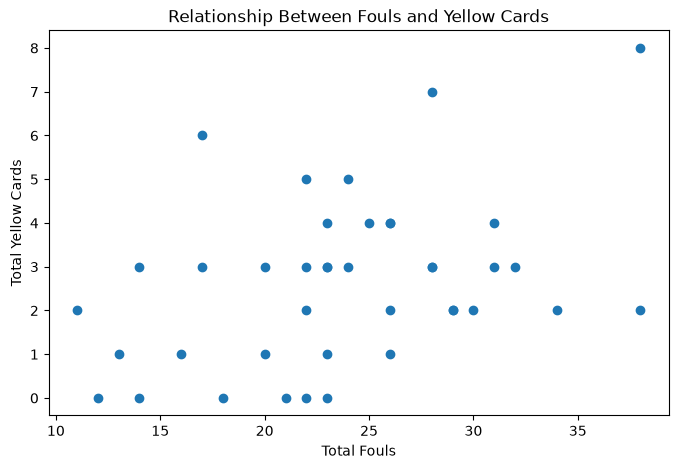

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(
        sample_df["TotalFouls"],
        sample_df["TotalYellow"]
    )

plt.title("Relationship Between Fouls and Yellow Cards")
plt.xlabel("Total Fouls")
plt.ylabel("Total Yellow Cards")
plt.show()
    

### Fouls analysis interpretation

The correlation value and scatter plot show whether matches with more fouls generally also had more yellow cards.

A positive correlation would mean that yellow cards tend to increase when the number of fouls increases. The strength of the relationship should be considered using the correlation value rather than only looking at the graph.
    

## Final Conclusion

 From the stratified sample, the estimated average number of yellow cards per completed match is approximately **2.63**.

The 95% confidence interval is approximately **2.01 to 3.24 cards per match**.

When comparing Group Stage and Knockout Stage matches, the average yellow cards were approximately **2.57** and **2.75** respectively. The test gave a p-value of approximately **0.808**, so there is not enough evidence to conclude that the two stage averages are different.

I also checked the relationship between fouls and yellow cards as an additional disciplinary analysis. This helps to see whether matches with more fouls tend to have more yellow cards.
    